In [1]:
#import torch
#!git clone https://github.com/facebookresearch/segment-anything-2
#%cd segment-anything-2
#!pip install -q -e .

In [2]:
#!curl -O https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt


In [3]:
#!sha256sum sam2_hiera_base_plus.pt

In [4]:
%cd C:\Users\Admin\segment-anything-2
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

C:\Users\Admin\anaconda3\envs\NC_Torch\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\Admin\segment-anything-2


In [5]:
import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
import json

In [6]:

train_data_dir=r"C:\Users\Admin\Desktop\Random_Train_51"
train_images_dir=os.path.join(train_data_dir, "images")
train_masks_dir=os.path.join(train_data_dir, "masks")
train_json_dir= os.path.join(train_data_dir, "labels.json")

with open(train_json_dir) as f:
    train_data=json.load(f)

all_train_data=[]
all_train_images=[]

for entry in train_data['images']:
    image_name=entry['image_name']
    masks=[label['mask_file'] for label in entry ['labels']]

    all_train_images.append({
        "image": os.path.join(train_images_dir, image_name),
        "masks": [os.path.join(train_masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

final_train_data=[]
for entry in all_train_images:
    for mask in entry['masks']:
        final_train_data.append({
            "image": entry["image"],
            "annotation": mask
        })
print(len(final_train_data))



test_data_dir=r"C:\Users\Admin\Desktop\New_Test_Dataset"
test_images_dir=os.path.join(test_data_dir, "images")
test_masks_dir=os.path.join(test_data_dir, "masks")
test_json_dir= os.path.join(test_data_dir, "labels.json")

with open(test_json_dir) as f:
    test_data=json.load(f)
    
all_test_data=[]
all_test_images=[]

for entry in test_data['images']:
    image_name=entry['image_name']
    masks=[label['mask_file'] for label in entry ['labels']]

    all_test_images.append({
        "image":os.path.join(test_images_dir, image_name),
        "masks": [os.path.join(test_masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

final_test_data=[]
for entry in all_test_images:
    for mask in entry['masks']:
        final_test_data.append({
            "image":entry["image"],
            "annotation":mask
        })

1221


In [7]:
len(final_test_data)

1061

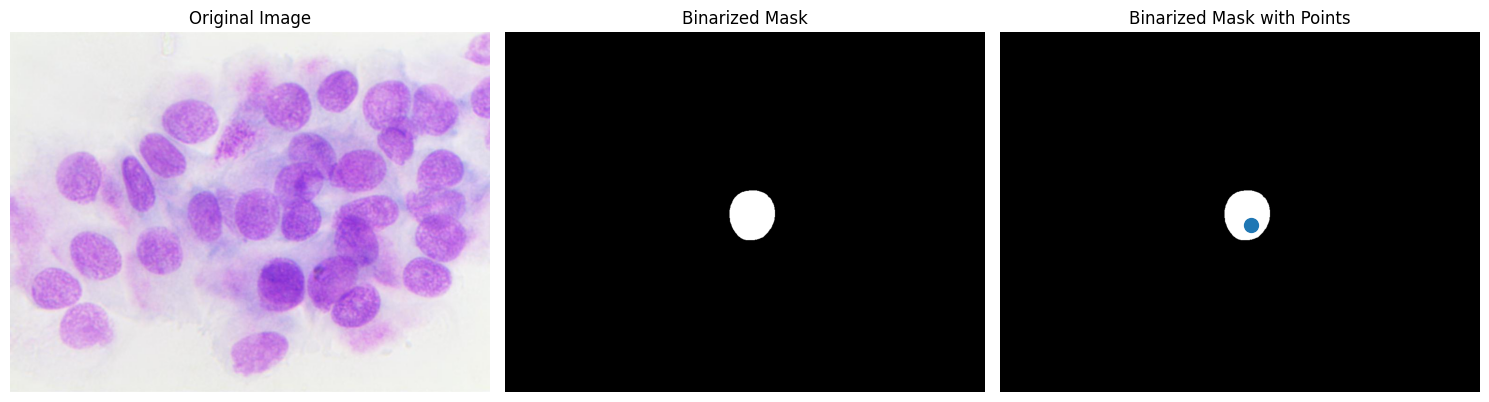

In [8]:
def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
    ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

    if Img is None or ann_map is None:
        print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
        return None, None, None, 0

    # Resize image and mask
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # Scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
    points=[]
    inds = np.unique(ann_map)[1:]
    for ind in inds:
        mask = (ann_map == ind).astype(np.uint8)
        binary_mask = np.maximum(binary_mask, mask)
    coords = np.argwhere(binary_mask > 0)
    if len(coords) > 0:
        for _ in inds:
            yx = np.array(coords[np.random.randint(len(coords))])
            points.append([yx[1], yx[0]])
    points = np.array(points)
    
    if visualize_data:
        # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')
        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()
        
    binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
    binary_mask = binary_mask.transpose((2, 0, 1))
    points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
    return Img, binary_mask, points, len(inds)

Img1, masks1, points1, num_masks = read_batch(final_train_data, visualize_data=True)

In [9]:
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra

# Clear GlobalHydra
GlobalHydra.instance().clear()

# Initialize Hydra
config_dir = r"C:\Users\Admin\segment-anything-2\sam2\configs\sam2"
config_name = "sam2_hiera_b+.yaml"
sam2_checkpoint = "sam2_hiera_base_plus.pt"

with initialize_config_dir(config_dir=config_dir, version_base=None):
    # Compose the configuration and build the model
    cfg = compose(config_name=config_name)
    sam2_model = build_sam2(config_name, sam2_checkpoint, device="cuda")

saved_checkpoint_path=r"C:\Users\Admin\Desktop\fine_tuned_sam2.torch"
predictor = SAM2ImagePredictor(sam2_model)
predictor.model.load_state_dict(torch.load(saved_checkpoint_path))


C:\Users\Admin\AppData\Local\Temp\ipykernel_14124\3347903458.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictor.model.load_state_dict(torch.load(saved_checkpoint

<All keys matched successfully>

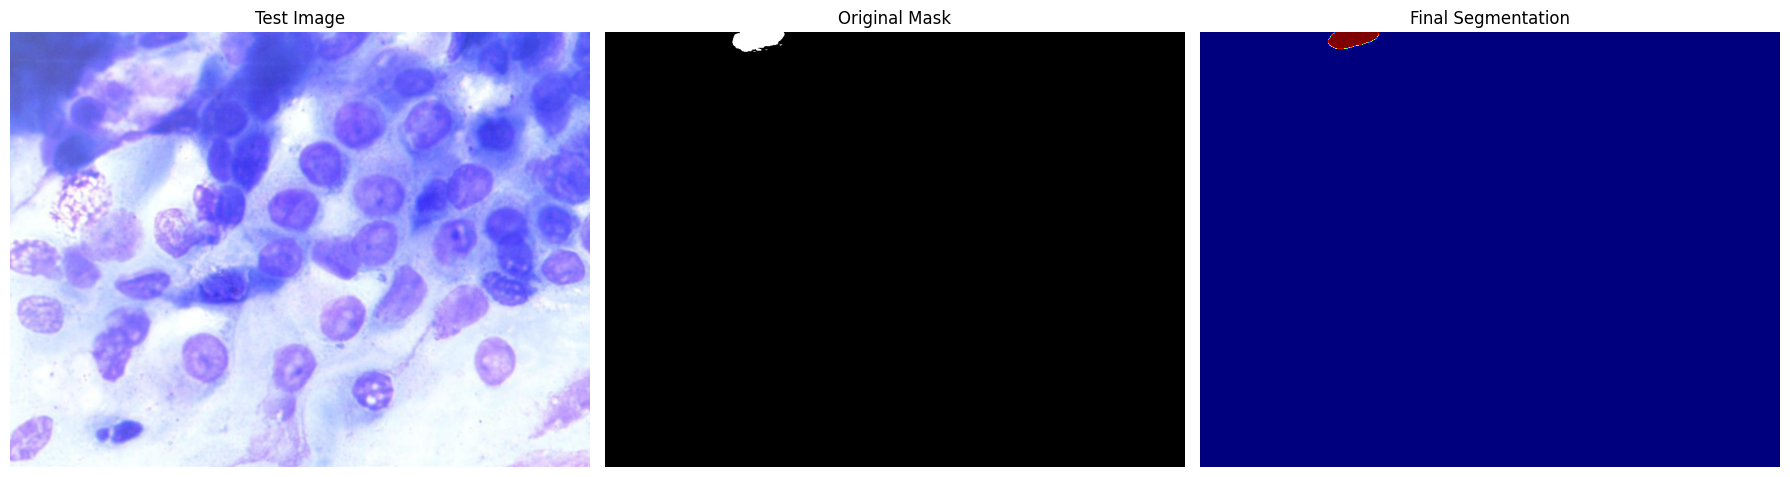

In [10]:
def read_image(image_path, mask_path):  # read and resize image and mask
    img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
    mask = cv2.imread(mask_path, 0)
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
    img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
    mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
    points = []
    coords = np.argwhere(mask > 0)
    for i in range(num_points):
        yx = np.array(coords[np.random.randint(len(coords))])
        points.append([[yx[1], yx[0]]])
    return np.array(points)

import random

# Randomly select a test image from the test_data
selected_entry = random.choice(final_test_data)
image_path = selected_entry['image']
mask_path = selected_entry['annotation']

# Load the selected image and mask
image, mask = read_image(image_path, mask_path)

# Generate random points for the input
num_samples = 30  # Number of points per segment to sample
input_points = get_points(mask, num_samples)

# Perform inference and predict masks
with torch.no_grad():
    predictor.set_image(image)
    masks, scores, logits = predictor.predict(
       point_coords=input_points,
       point_labels=np.ones([input_points.shape[0], 1])
   )

# Process the predicted masks and sort by scores
np_masks = np.array(masks[:, 0])
np_scores = scores[:, 0]
sorted_masks = np_masks[np.argsort(np_scores)][::-1]

seg_map = np.zeros_like(sorted_masks[0], dtype=np.uint8)
occupancy_mask = np.zeros_like(sorted_masks[0], dtype=bool)

for i in range(sorted_masks.shape[0]):
    mask = sorted_masks[i]
    if (mask * occupancy_mask).sum() / mask.sum() > 0.15:
        continue

    mask_bool = mask.astype(bool)
    mask_bool[occupancy_mask] = False  # Set overlapping areas to False in the mask
    seg_map[mask_bool] = i + 1  # Use boolean mask to index seg_map
    occupancy_mask[mask_bool] = True  # Update occupancy_mask

# Visualization: Show the original image, mask, and final segmentation side by side
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title('Test Image')
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Original Mask')
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Final Segmentation')
plt.imshow(seg_map, cmap='jet')
plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
from tqdm import tqdm
import torch
import numpy as np
from sklearn.metrics import jaccard_score

def calculate_mean_iou(test_data, predictor, num_samples=30, device="cuda"):

    total_iou = 0.0
    count = 0
    
    # Initialize progress bar
    with tqdm(total=len(test_data), desc="Evaluating IoU", unit="image") as pbar:
        for entry in test_data:
            # Load image and mask
            image_path = entry['image']
            mask_path = entry['annotation']
            
            # Load and preprocess the image and mask
            image = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
            gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            if image is None or gt_mask is None:
                print(f"Warning: Could not load image or mask for {image_path}. Skipping...")
                pbar.update(1)
                continue
            
            # Resize image and mask
            scale = min(1024 / image.shape[1], 1024 / image.shape[0])
            image_resized = cv2.resize(image, (int(image.shape[1] * scale), int(image.shape[0] * scale)))
            gt_mask_resized = cv2.resize(gt_mask, (image_resized.shape[1], image_resized.shape[0]), interpolation=cv2.INTER_NEAREST)
            
            # Generate random input points from the ground truth mask
            input_points = []
            unique_labels = np.unique(gt_mask_resized)[1:]  # Exclude background (0)
            for label in unique_labels:
                mask = (gt_mask_resized == label).astype(np.uint8)
                coords = np.column_stack(np.where(mask > 0))
                sampled_coords = coords[np.random.choice(len(coords), min(num_samples, len(coords)), replace=False)]
                input_points.extend(sampled_coords.tolist())
            
            # input_points = np.array(input_points)
            input_points = get_points(gt_mask, num_samples)
            input_points_tensor = torch.tensor(input_points, dtype=torch.float32, device=device).unsqueeze(0)
            
            # Perform inference
            with torch.no_grad():
                predictor.set_image(image_resized)
                masks, scores, logits = predictor.predict(
                    point_coords=input_points,
                    point_labels=np.ones([input_points.shape[0], 1])
                )
            
            # Select the highest-confidence predicted mask
            np_masks = np.array(masks[:, 0])  # Predicted masks as numpy array
            np_scores = np.array(scores[:, 0])  # Scores for the masks
            sorted_indices = np.argsort(np_scores)[::-1]  # Sort by descending score
            pred_mask = np_masks[sorted_indices[0]]  # Highest score mask
            pred_mask_binary = (pred_mask > 0).astype(np.uint8)
            
            # Calculate IoU for this image
            iou = jaccard_score(
                gt_mask_resized.flatten(),
                pred_mask_binary.flatten(),
                average="micro"
            )
            
            total_iou += iou
            count += 1
            
            # Update progress bar
            pbar.set_postfix({"IoU": f"{iou:.4f}"})
            pbar.update(1)
    
    mean_iou = total_iou / count if count > 0 else 0
    return mean_iou

In [13]:
mean_test_iou=calculate_mean_iou(final_test_data, predictor)
print(mean_test_iou)

Evaluating IoU: 100%|██████████| 1061/1061 [04:51<00:00,  3.64image/s, IoU=0.9868]

0.9809602682268768
